# Phase 1 / Phase 2 Visualisation — Dissertation Figures

**Cross-dataset diabetic retinopathy (EyePACS + OLIVES) — MSc dissertation.**

This notebook is a **thin orchestrator**: all plotting logic lives in
`src/analysis/figures.py`. It is **plotting-only** — it reads the frozen
Phase 1 / Phase 2 feature tensors, the diagnostics JSON, and the training
histories that already exist on Google Drive, and renders dissertation-ready
figures. **No retraining, no GPU, no feature re-extraction, and the encoder is
never loaded.** A CPU runtime is fine.

Every figure is saved as **PNG** (dpi 200, for the slide deck) and **PDF**
(vector, for the dissertation) to `…/dissertation/figures/`, using a single
colourblind-safe style (Okabe–Ito blue/orange for the two datasets, viridis for
DR severity).

Generated: 2026-07-04 · Phase 2 complete (frozen).

## 1. Setup & Drive mount

Mount Google Drive, restore the repository, `cd` into it, and build a
`FiguresConfig` from the frozen `configs/diagnostics.yaml` (same Drive paths the
diagnostics used). We also define a tiny helper to display the saved PNGs
inline so the reader sees exactly the artefacts written to disk.

In [ ]:
# Mount Drive and restore the repo (skip the git block if running locally).
from google.colab import drive, userdata
import os

drive.mount('/content/drive')

REPO_DIR = "/content/dr-dissertation"
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/savita10/dr-dissertation.git {REPO_DIR}
else:
    !git -C {REPO_DIR} fetch origin && git -C {REPO_DIR} reset --hard origin/main
%cd {REPO_DIR}

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no GPU — set Runtime → Change runtime type → GPU")

Mounted at /content/drive
Cloning into '/content/dr-dissertation'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 318 (delta 153), reused 235 (delta 74), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 1.57 MiB | 19.86 MiB/s, done.
Resolving deltas: 100% (153/153), done.


In [ ]:
%cd /content/dr-dissertation

/content/dr-dissertation


In [ ]:
# Import the plotting module and build the config from the frozen diagnostics YAML.
from pathlib import Path
from IPython.display import Image, display

from src.analysis import figures

cfg = figures.FiguresConfig.from_diagnostics_yaml('configs/diagnostics.yaml')
cfg.figures_dir.mkdir(parents=True, exist_ok=True)  # ensure the output folder exists
print('features_dir :', cfg.features_dir)
print('reports_dir  :', cfg.reports_dir)
print('figures_dir  :', cfg.figures_dir)


def show(result):
    """Display every PNG referenced (at any nesting depth) by a figure result."""
    if result is None:
        print('(figure skipped — see the note printed above)')
        return
    def walk(v):
        if isinstance(v, dict):
            for x in v.values():
                walk(x)
        elif isinstance(v, Path) and v.suffix == '.png':
            display(Image(filename=str(v)))
    walk(result)

features_dir : /content/drive/MyDrive/dissertation/features
reports_dir  : /content/drive/MyDrive/dissertation/reports
figures_dir  : /content/drive/MyDrive/dissertation/figures


## 2. STEP 1 — artefact introspection

Before plotting, we print the **actual schema** of the saved files (type, dict
keys, and every tensor/array shape + dtype) so the plotting code is matched to
the real keys rather than an assumed layout. We expect the Phase 1 files to hold
only `features` + `metadata`, and the Phase 2 files to additionally carry
`labels` (EyePACS DR grades) and `image_stats` (incl. the `black_pixel`
black-border proportion) — everything the figures need. We also print the
`phase2_results.json` keys and the `coral_on/full` severity means block.

In [ ]:
# Load each artefact and print its structure — do NOT assume the schema.
import json
import torch

FEATURES = cfg.features_dir
for name in [
    'eyepacs_resnet50_features.pt', 'olives_resnet50_features.pt',
    'phase2_coral_on_full_eyepacs_features.pt',
    'phase2_coral_on_full_olives_features.pt',
]:
    obj = torch.load(FEATURES / name, map_location='cpu', weights_only=False)
    print(name, '->', type(obj).__name__)
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, dict):  # e.g. image_stats / metadata
                print('   ', k, '(dict):', list(v.keys()))
            else:
                print('   ', k, getattr(v, 'shape', type(v).__name__),
                      getattr(v, 'dtype', ''))
    print()

eyepacs_resnet50_features.pt -> dict
    features torch.Size([35108, 2048]) torch.float32
    metadata (dict): ['dataset_name', 'n_samples', 'feature_dim', 'extraction_date', 'model_name']

olives_resnet50_features.pt -> dict
    features torch.Size([3142, 2048]) torch.float32
    metadata (dict): ['dataset_name', 'n_samples', 'feature_dim', 'extraction_date', 'model_name']

phase2_coral_on_full_eyepacs_features.pt -> dict
    features torch.Size([35108, 2048]) torch.float32
    labels torch.Size([35108]) torch.int64
    image_stats (dict): ['brightness', 'black_pixel', 'contrast']
    metadata (dict): ['arm', 'split', 'feature_dim', 'model_name', 'extraction_date', 'provenance', 'dataset', 'n_samples']

phase2_coral_on_full_olives_features.pt -> dict
    features torch.Size([3142, 2048]) torch.float32
    labels NoneType 
    image_stats (dict): ['brightness', 'black_pixel', 'contrast']
    metadata (dict): ['arm', 'split', 'feature_dim', 'model_name', 'extraction_date', 'provenance',

In [ ]:
# Diagnostics JSON: top-level keys + the severity means the ordering figure uses.
with open(cfg.reports_dir / 'phase2_results.json', encoding='utf-8') as fh:
    results = json.load(fh)
print('phase2_results.json keys :', list(results.keys()))
print('results arms/splits      :',
      {a: list(results['results'][a].keys()) for a in results['results']})
print('coral_on/full severity means:')
print(json.dumps(results['results']['coral_on']['full']['severity']['means'], indent=2))

phase2_results.json keys : ['generated', 'phase1_baseline', 'targets', 'results']
results arms/splits      : {'coral_on': ['full', 'test'], 'coral_off': ['full', 'test']}
coral_on/full severity means:
{
  "class_0": -0.6209802031517029,
  "class_1": -0.541472315788269,
  "class_2": 1.238032341003418,
  "class_3": 4.400669097900391,
  "class_4": 4.9651970863342285,
  "eyepacs_all": -0.0980740338563919,
  "olives": 1.095869541168213,
  "pc1_explained_variance": 0.06471516191959381,
  "pc2_explained_variance": 0.04038028419017792
}


## Figure 1 — Dataset summary table

A side-by-side summary of EyePACS (single-modality fundus) and OLIVES
(multimodal, three-tier). It grounds the reader in the scale and label structure
of the two datasets before any modelling result is shown. EyePACS DR-grade
counts are read from the saved labels; OLIVES tier/patient counts come from the
data chapter.

[figures] wrote fig01_dataset_summary: fig01_dataset_summary.png, fig01_dataset_summary.pdf


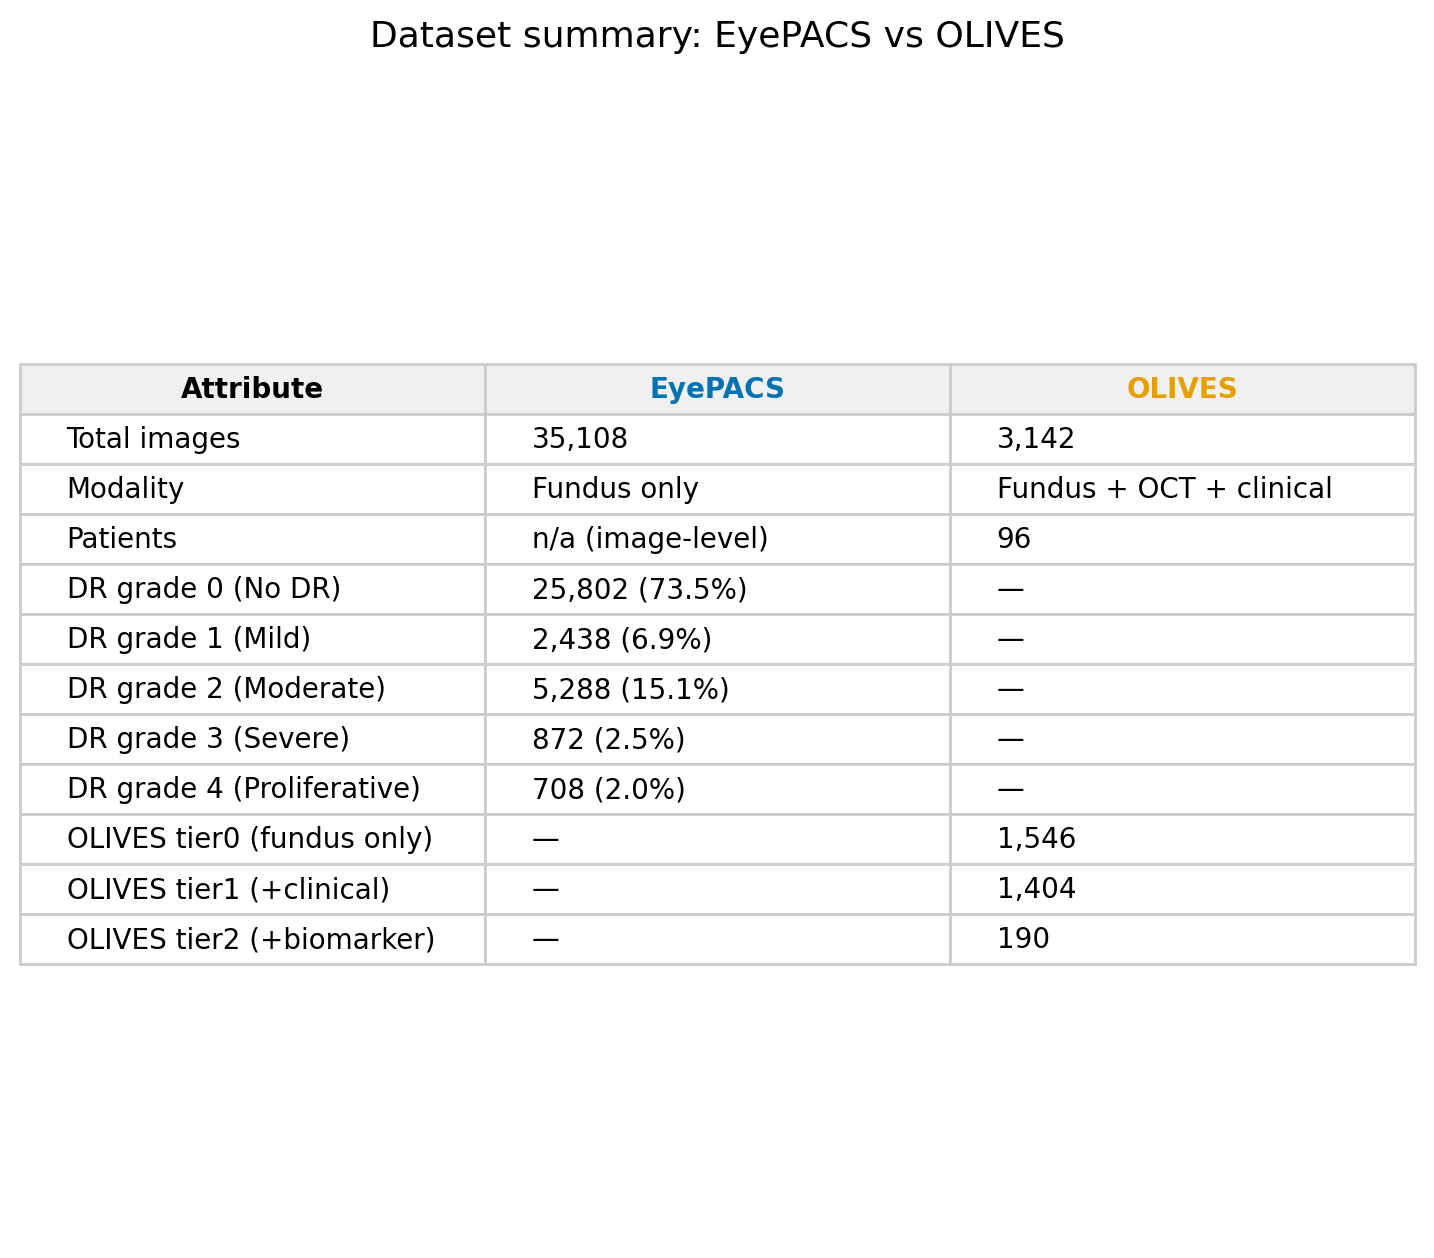

In [ ]:
show(figures.fig_dataset_summary_table(cfg))  # renders table PNG/PDF + a CSV

## Figure 2 — Acquisition PCA (before training)

PCA on the combined Phase 1 ImageNet features, coloured by dataset. It shows
that *before* any training the two datasets separate along PC1, and that PC1
tracks the black-border (field-stop) proportion (ρ ≈ −0.274) — i.e. the dominant
axis is camera geometry, not pathology. This is the problem Phase 2 sets out to
fix.

[figures] wrote fig02_acquisition_pca: fig02_acquisition_pca.png, fig02_acquisition_pca.pdf


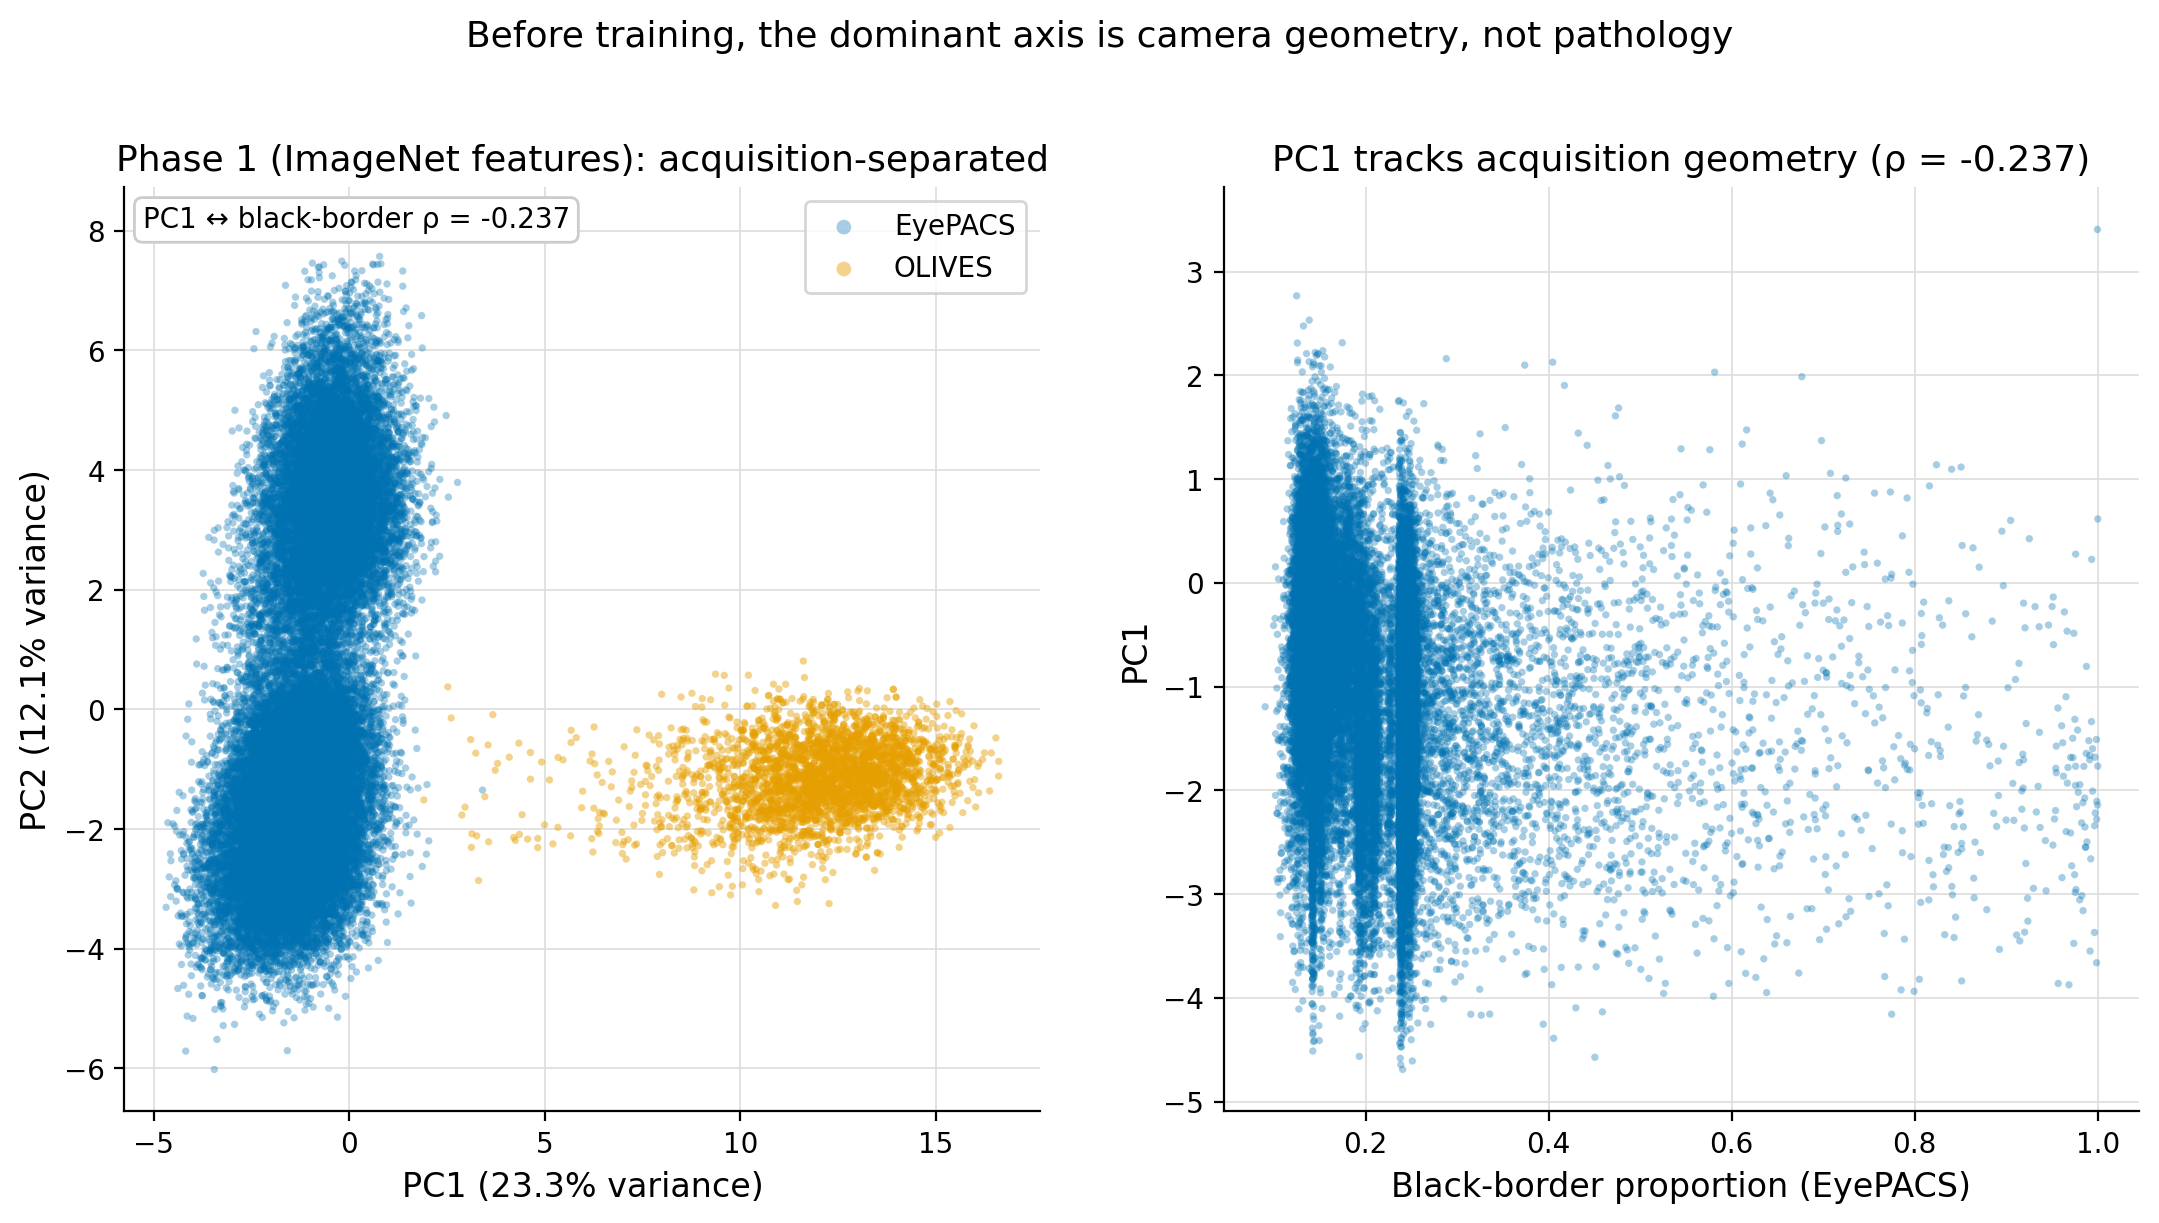

In [ ]:
show(figures.fig_acquisition_pca(cfg))

## Figure 3 — Example fundus images (optional)

A few de-normalised EyePACS vs OLIVES fundus images side by side to illustrate
the field-stop/border difference driving the Phase 1 gap. This step loads
preprocessed image tensors, so it is best-effort: if they are not readily
available (or memory is tight) the function prints a note and is skipped without
affecting any other figure.

[figures] wrote fig03_example_fundus: fig03_example_fundus.png, fig03_example_fundus.pdf


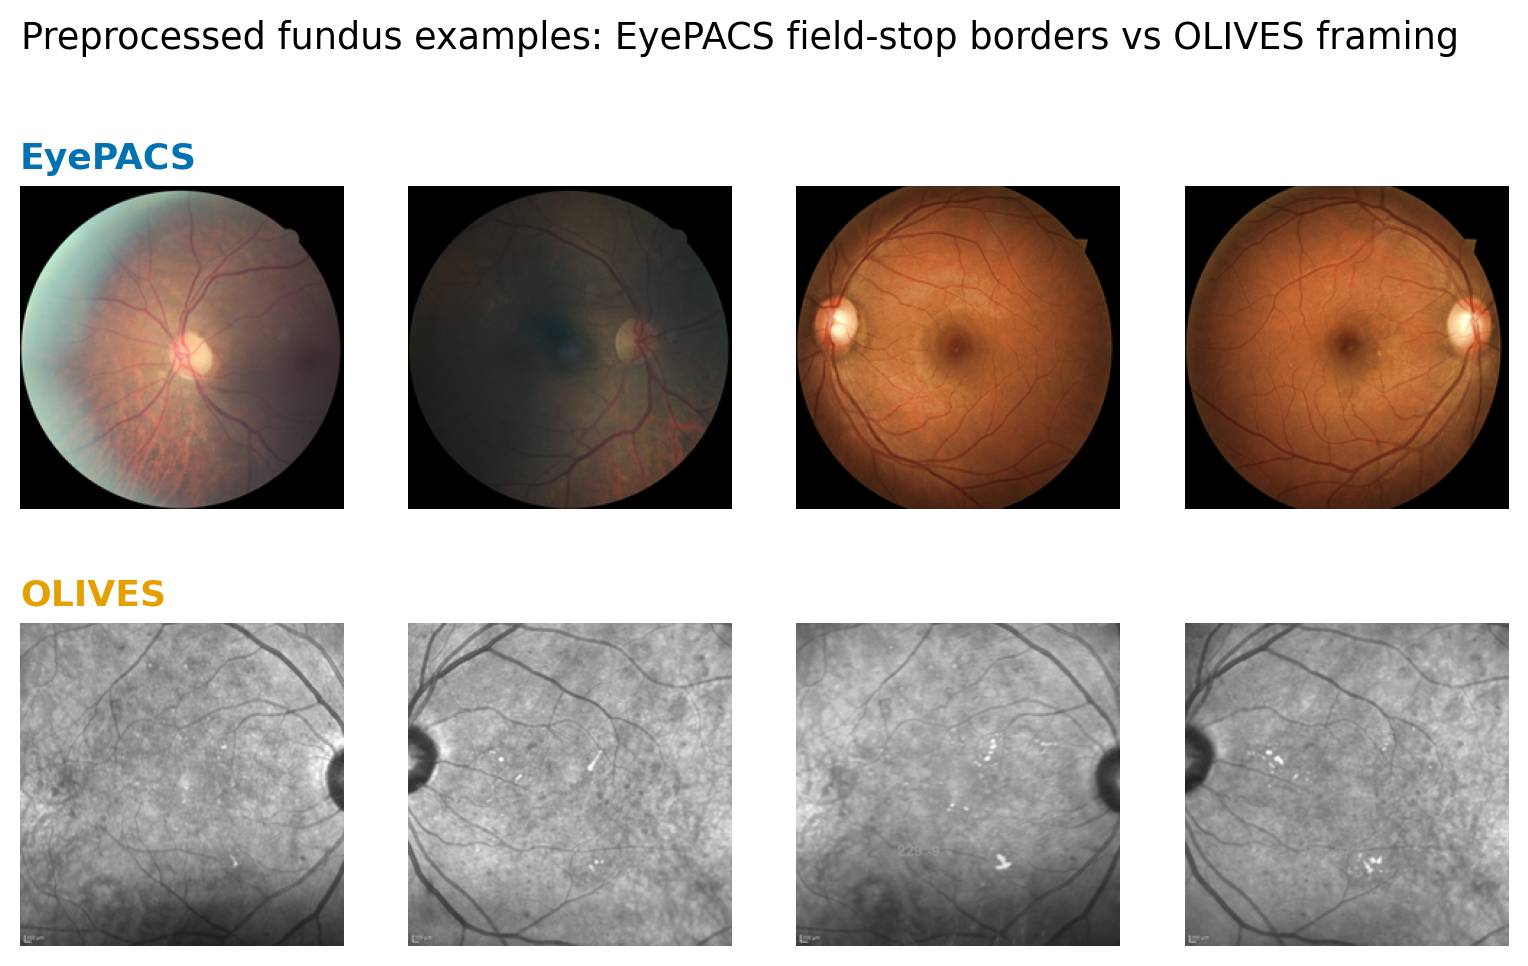

In [ ]:
show(figures.fig_example_fundus(cfg))

## Figure 4 — Training curves

(a) Validation DR quadratic-weighted-kappa (QWK) per epoch for both arms, with
the best epoch marked; (b) the per-term training losses
(dr/biomarker/regression/supcon/coral/total) for `coral_on`. Together they show
training stability and which objective terms actually move during optimisation.

[figures] wrote fig04a_training_qwk: fig04a_training_qwk.png, fig04a_training_qwk.pdf
[figures] wrote fig04b_training_losses: fig04b_training_losses.png, fig04b_training_losses.pdf


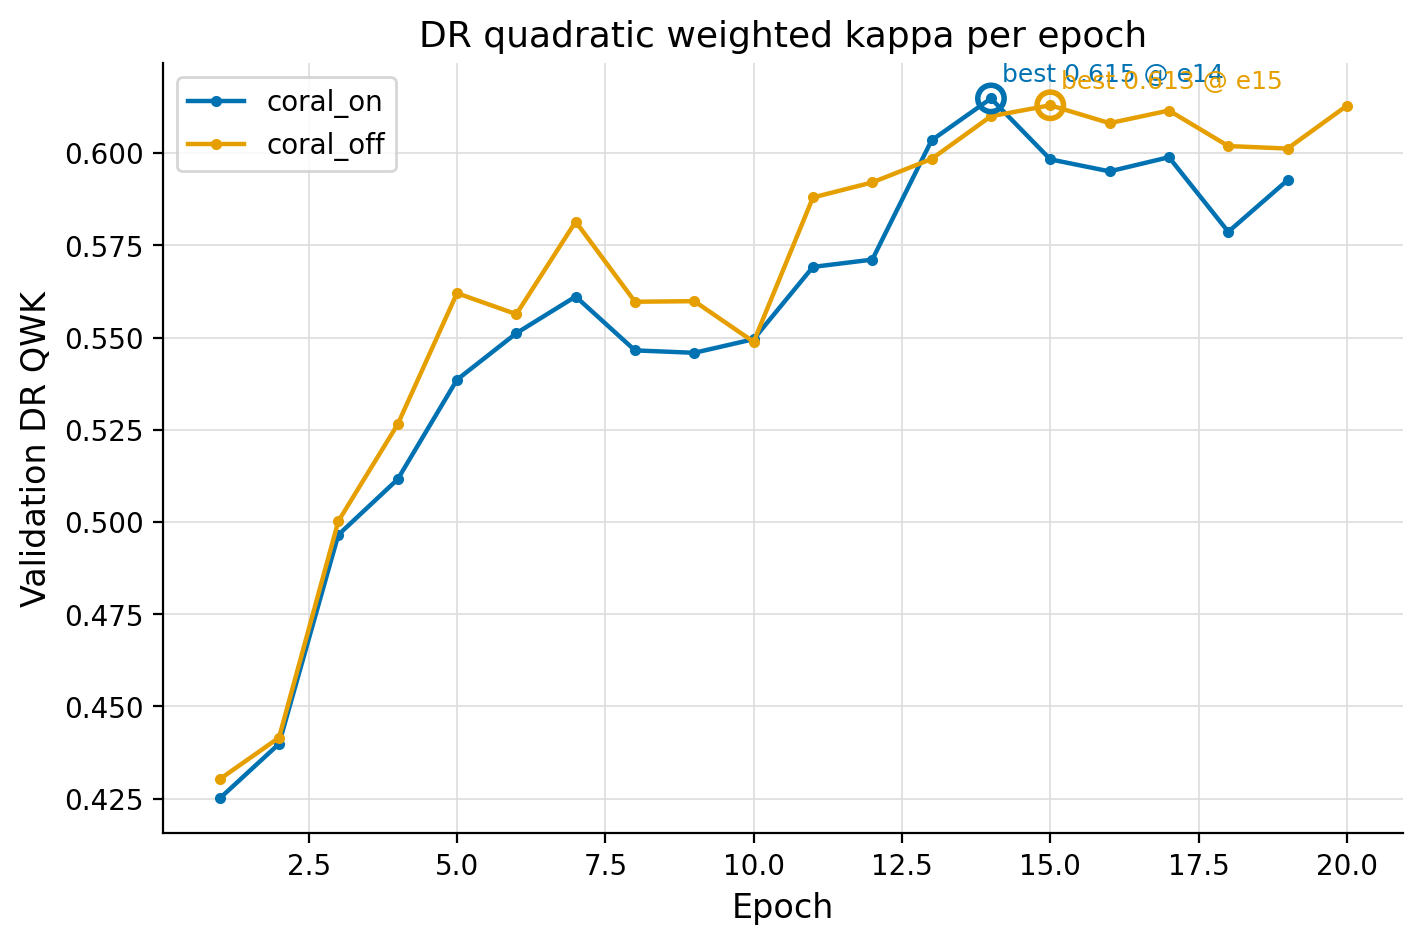

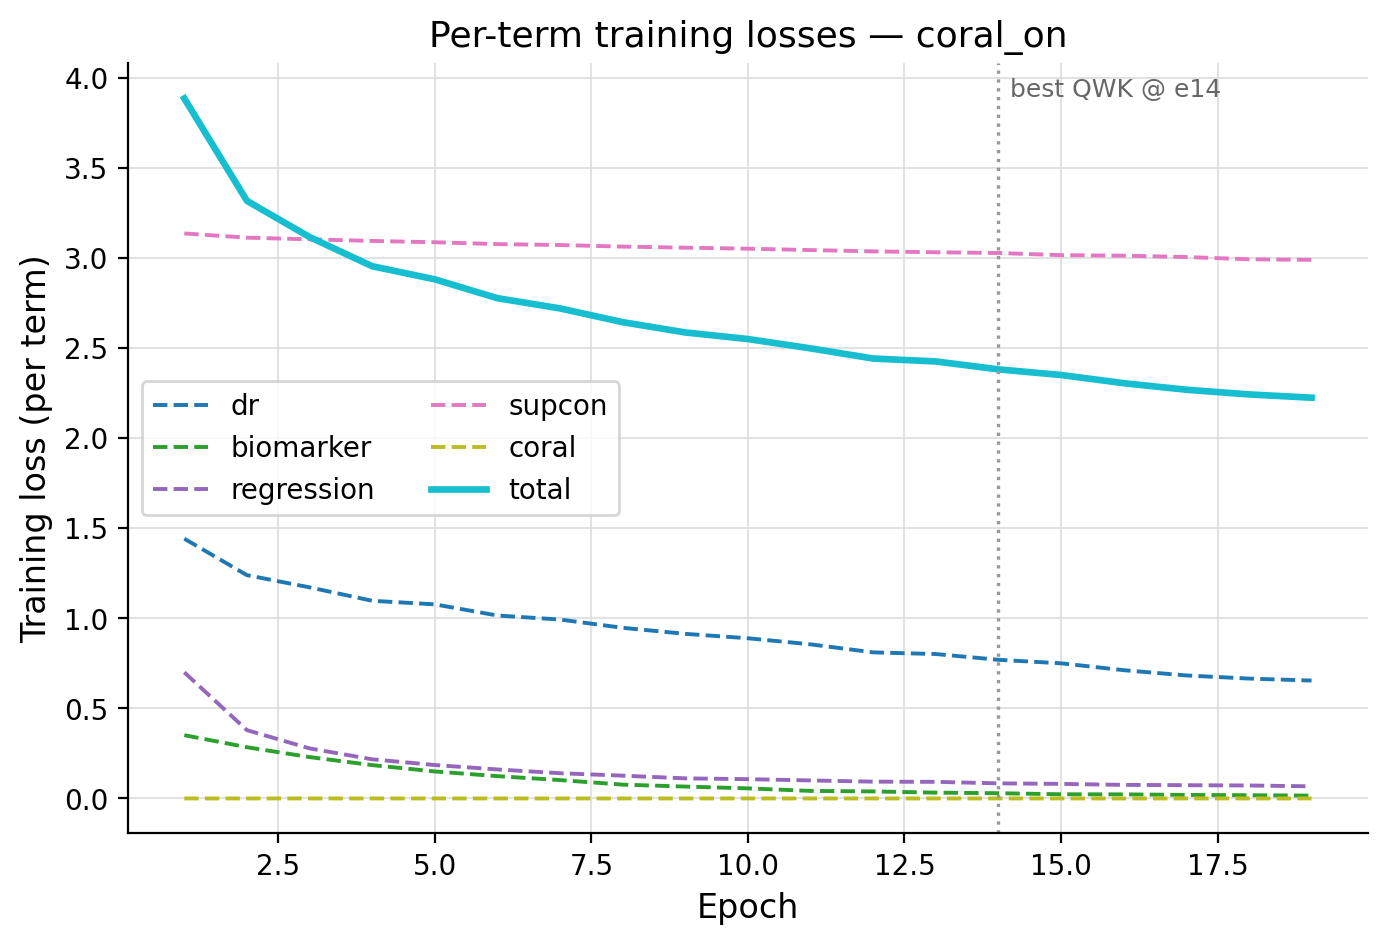

In [ ]:
show(figures.fig_training_curves(cfg))

## Figure 5 — Cross-dataset FID before/after

Fréchet distance between the EyePACS and OLIVES feature distributions: Phase 1
(240.65) → `coral_off` (77.50) → `coral_on` (74.64), a ≈ −69% drop. The two
trained arms are within a few FID of each other, so the caption notes honestly
that the CORAL term is only marginal and augmentation is the main mechanism.

[figures] wrote fig05_fid_bar: fig05_fid_bar.png, fig05_fid_bar.pdf


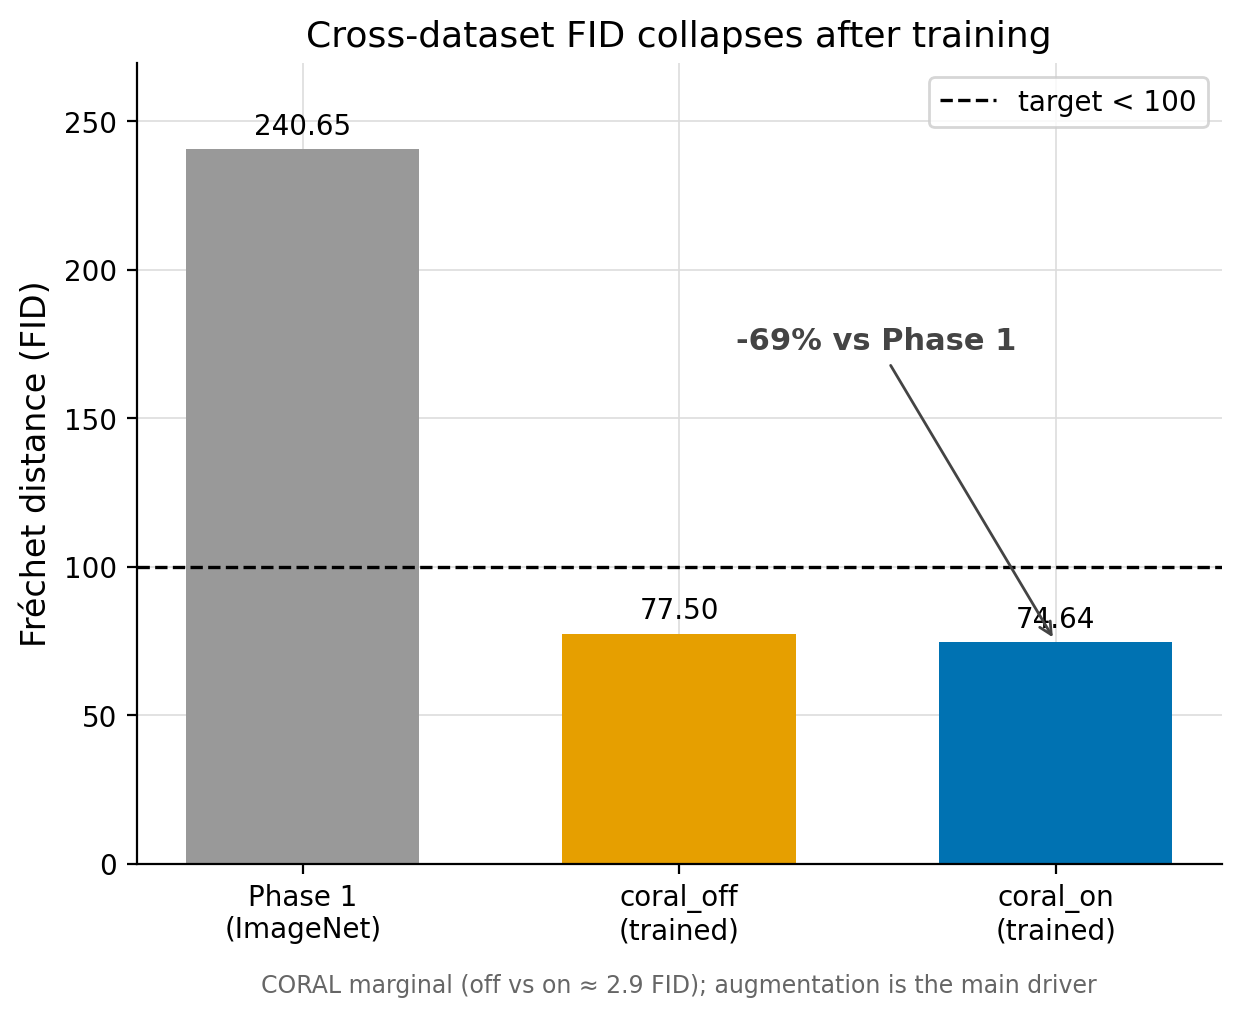

In [ ]:
show(figures.fig_fid_bar(cfg))

## Figure 6 — PCA before/after (marquee figure)

The core Phase 2 result: a before panel (Phase 1 features, acquisition-separated)
and an after panel (`coral_on` features), both coloured by dataset, plus a second
version of the after panel coloured by EyePACS DR severity. The dominant axis
flips from acquisition geometry to a representation where the datasets overlap
and severity is ordered.

[figures] wrote fig06a_pca_before_after: fig06a_pca_before_after.png, fig06a_pca_before_after.pdf
[figures] wrote fig06b_pca_after_severity: fig06b_pca_after_severity.png, fig06b_pca_after_severity.pdf


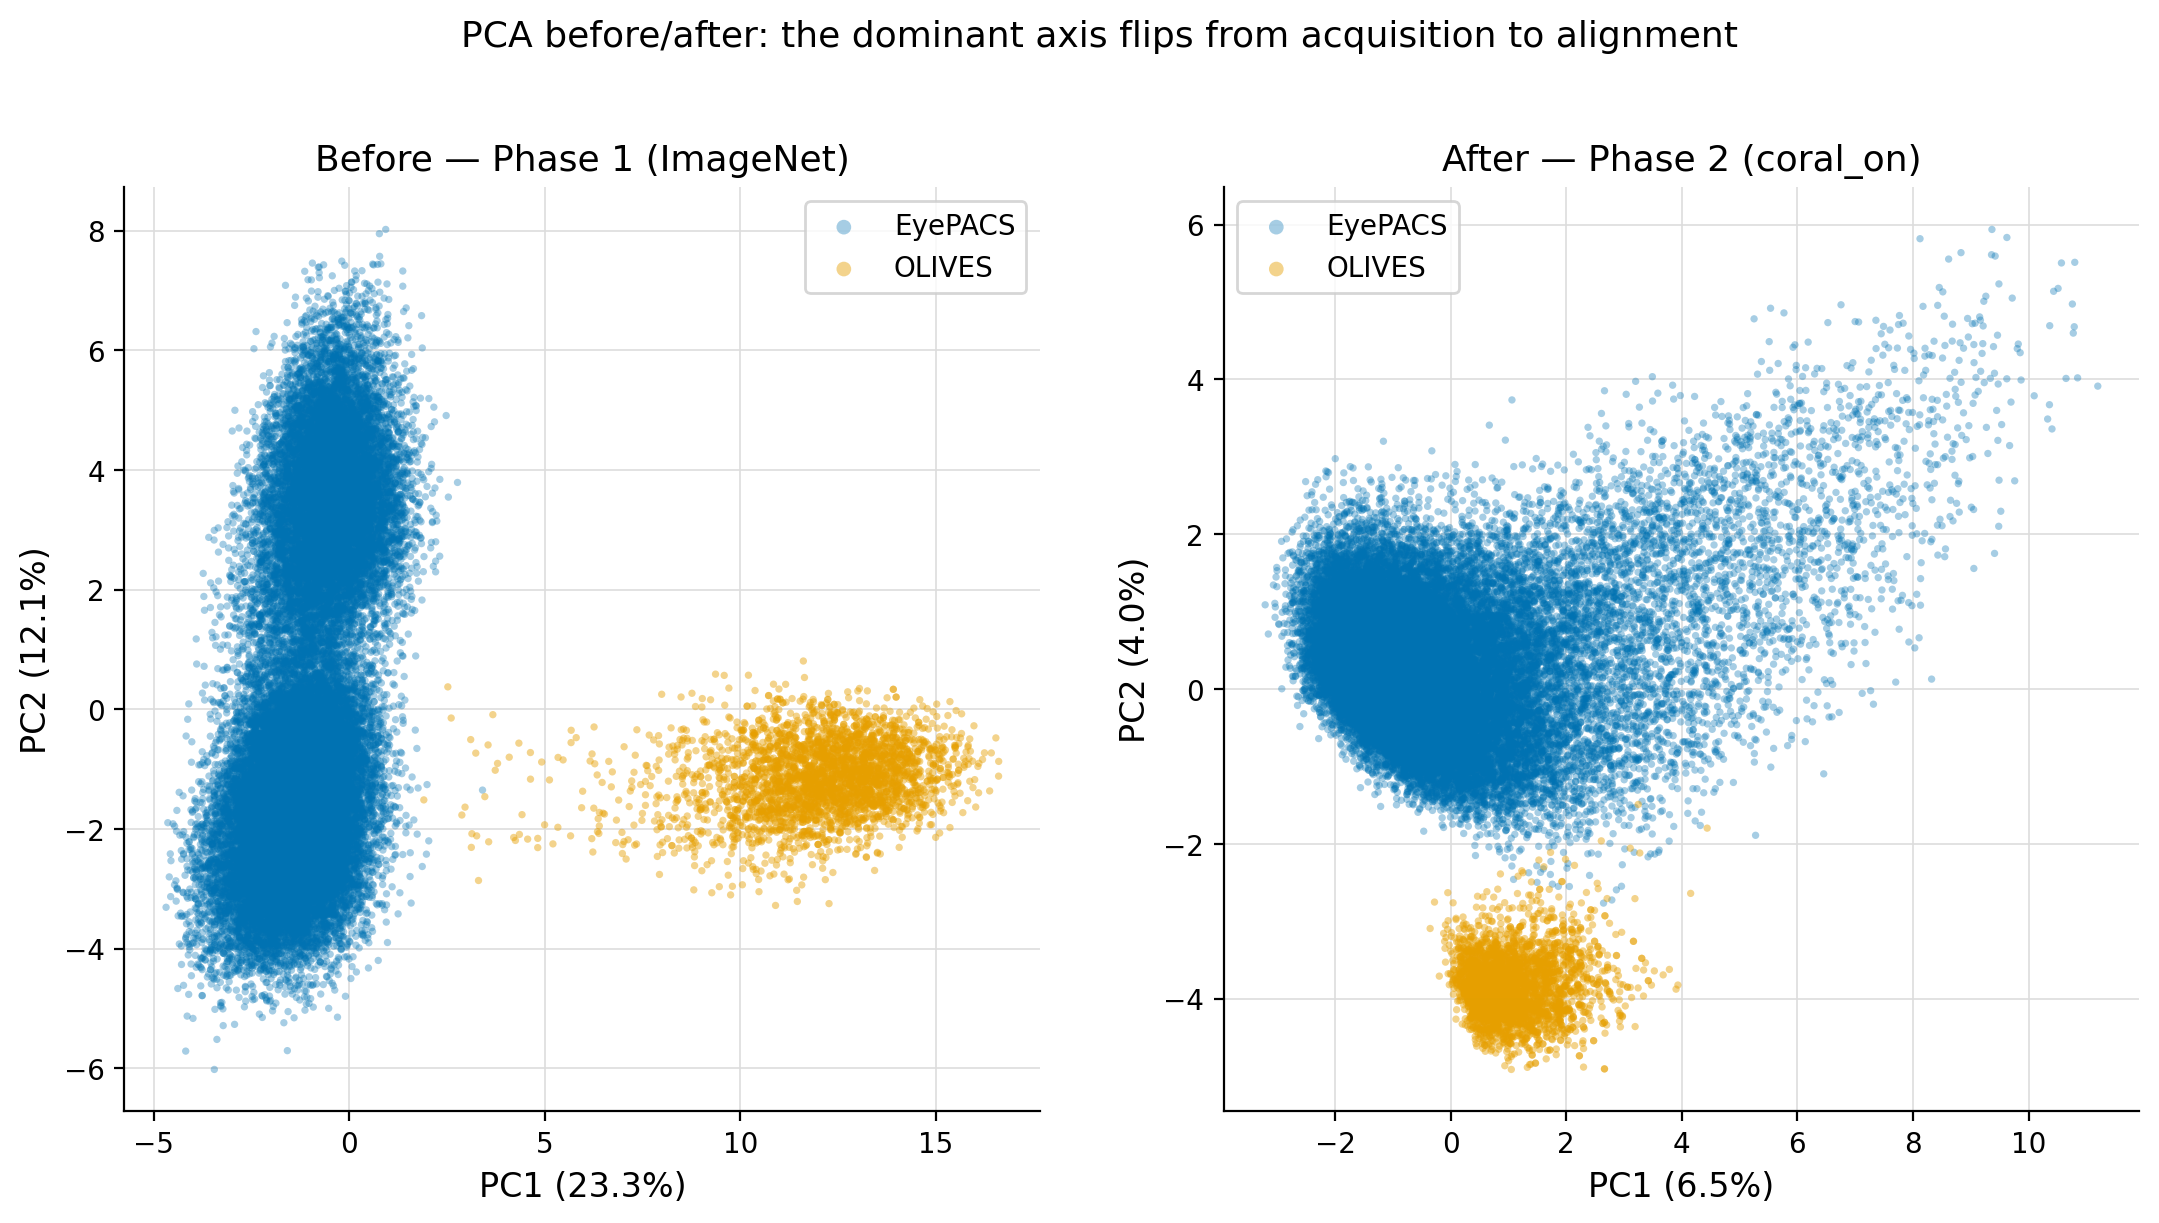

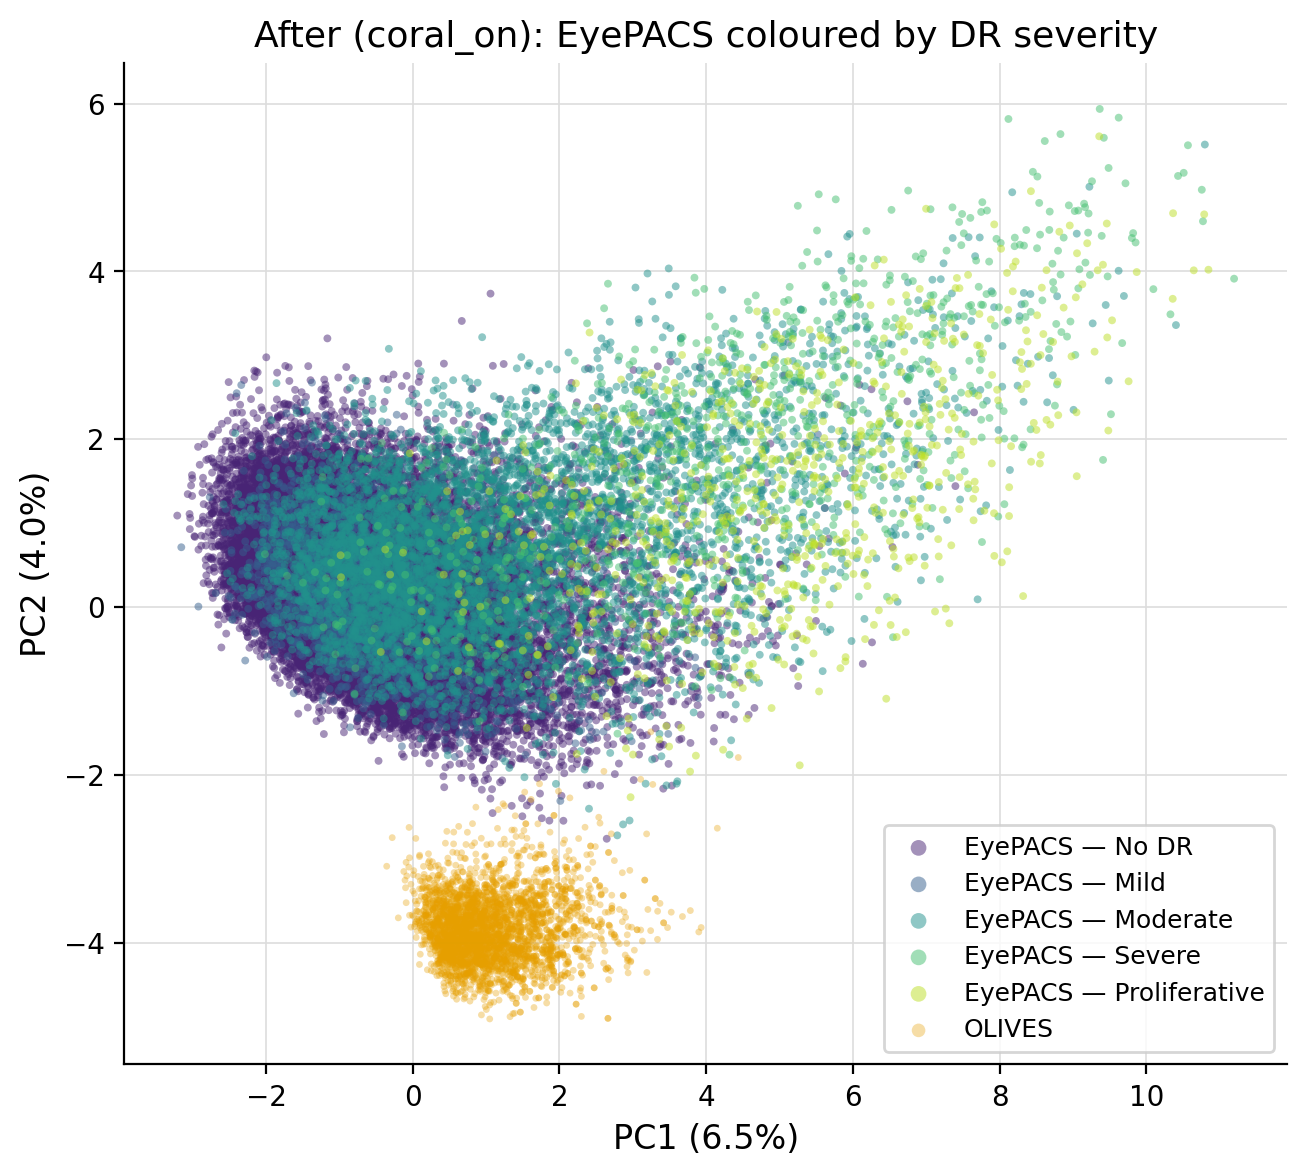

In [ ]:
show(figures.fig_pca_before_after(cfg))

## Figure 7 — Joint UMAP / t-SNE embedding

A single 2-D embedding of the combined `coral_on` features, plotted twice: by
dataset (the two datasets should intermix = alignment succeeded) and by DR
severity (grades should separate = pathology is preserved). Uses UMAP if
available, else t-SNE; EyePACS is subsampled for tractability (stated in the
figure caption).

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[figures] fig_tsne_umap_joint using UMAP (EyePACS n=6000, OLIVES n=3142)
[figures] wrote fig07a_embed_by_dataset: fig07a_embed_by_dataset.png, fig07a_embed_by_dataset.pdf
[figures] wrote fig07b_embed_by_severity: fig07b_embed_by_severity.png, fig07b_embed_by_severity.pdf


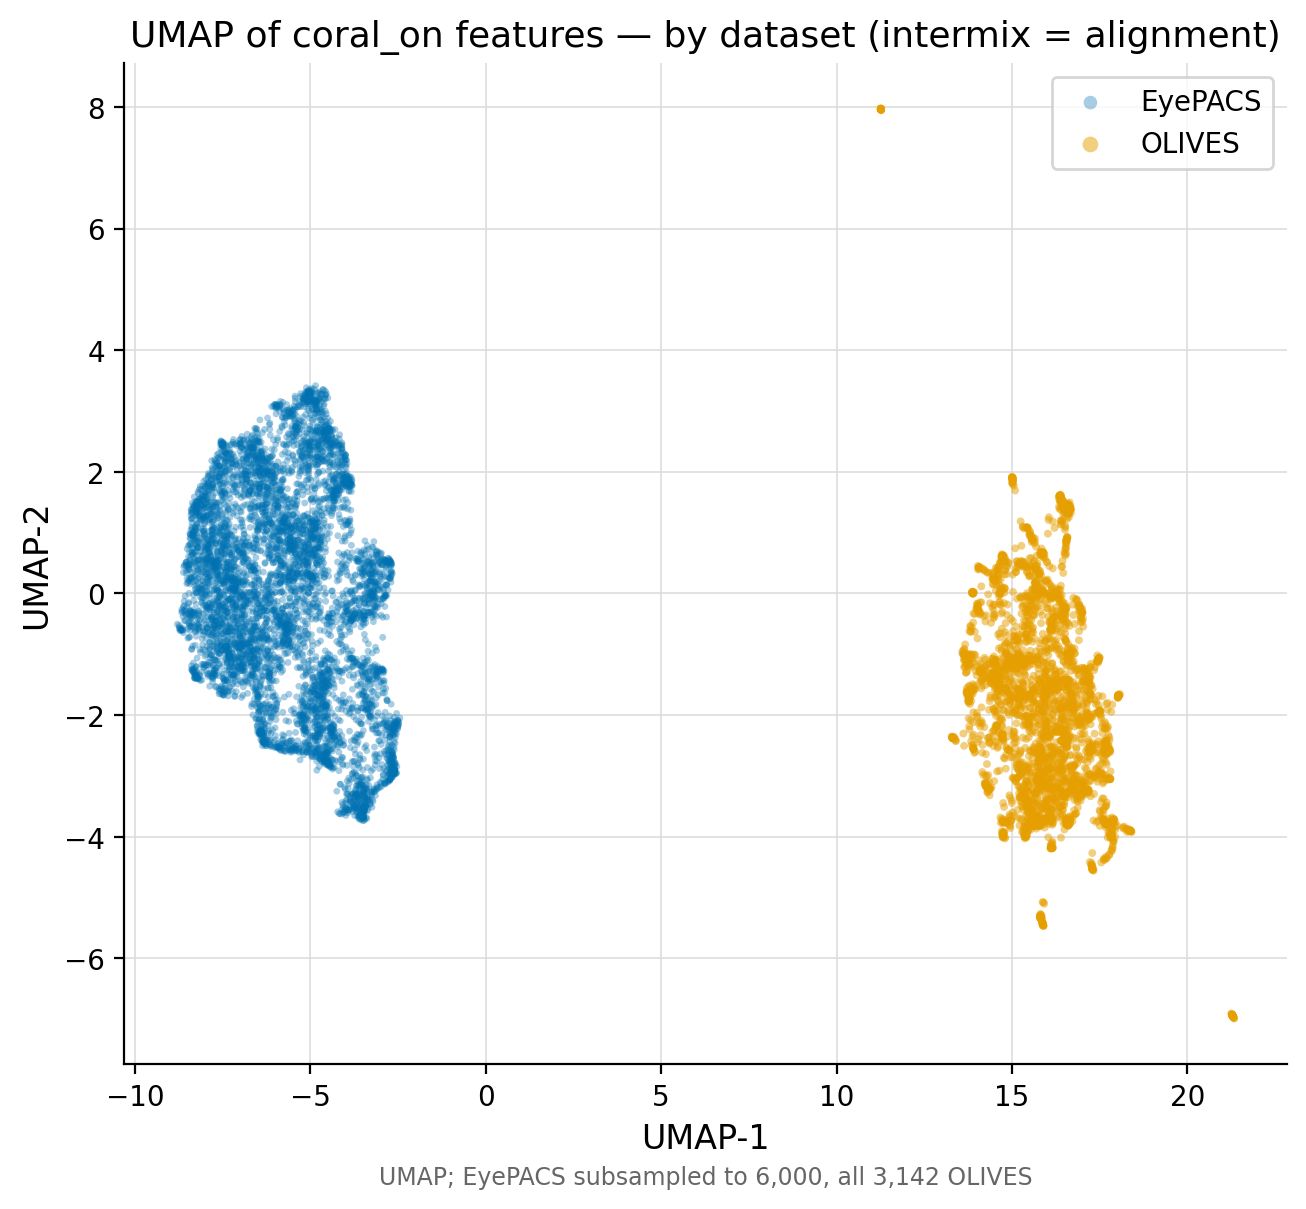

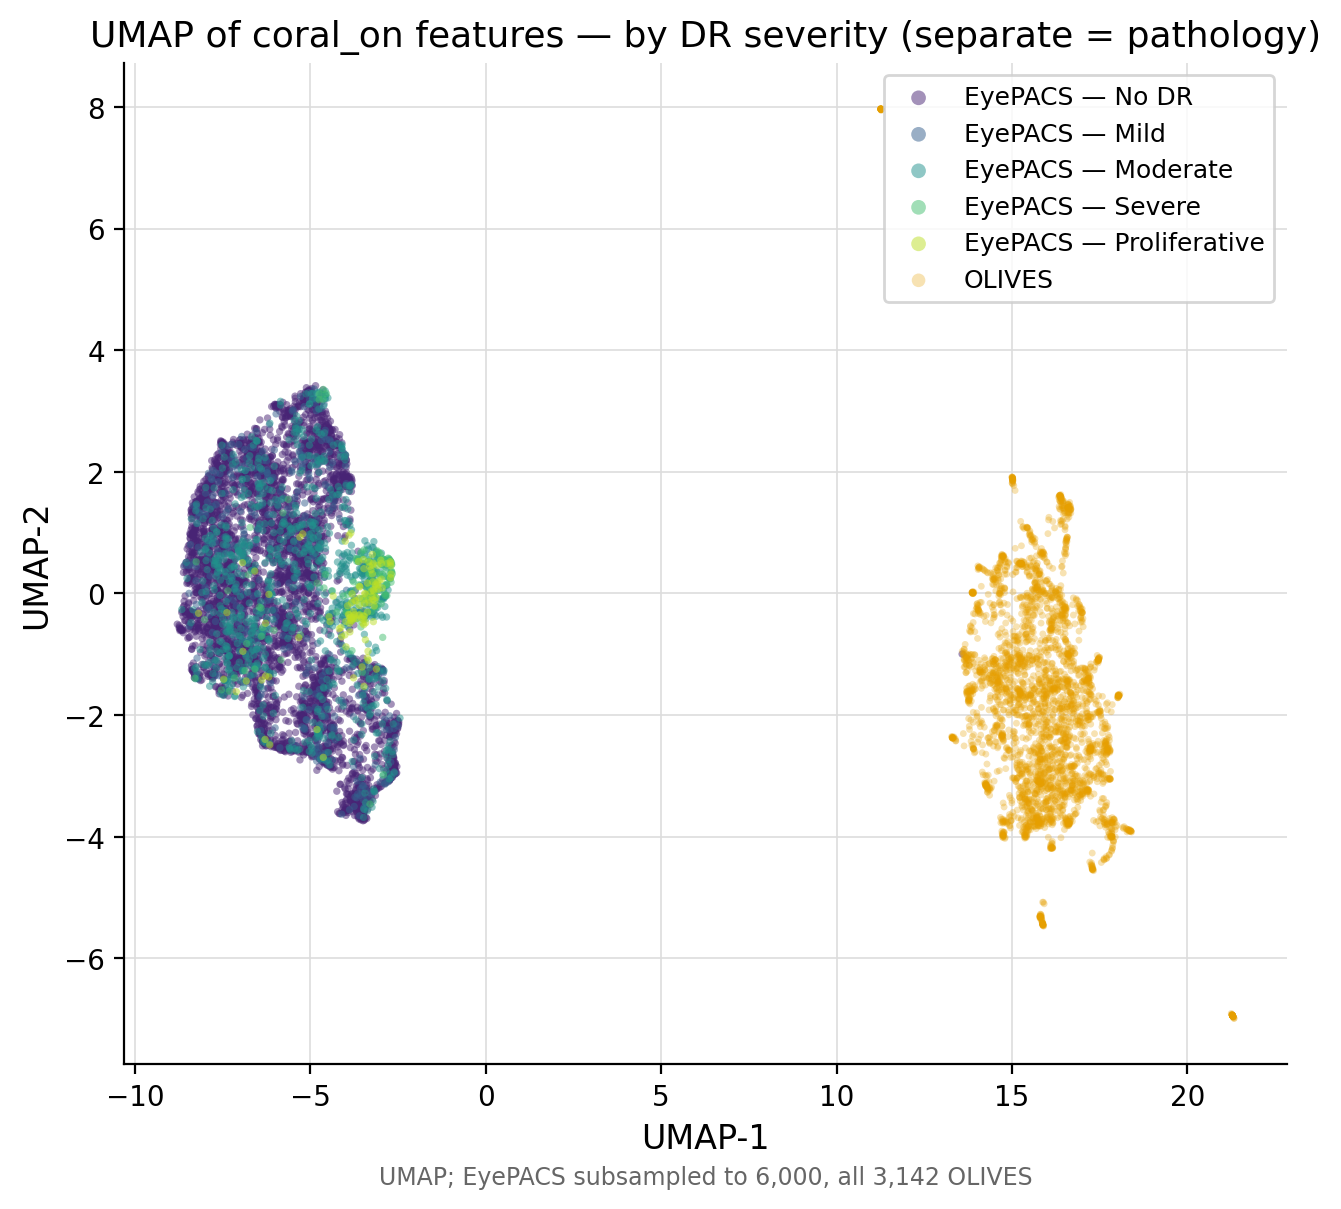

In [ ]:
show(figures.fig_tsne_umap_joint(cfg))

## Figure 8 — Severity ordering on PC1

Mean PC1 coordinate per EyePACS DR grade (0–4) from the diagnostics JSON. The
monotonic staircase (rank ρ = 1.00) confirms that, after training, PC1 encodes
disease severity rather than acquisition — the complement to Figure 9.

[figures] wrote fig08_severity_ordering: fig08_severity_ordering.png, fig08_severity_ordering.pdf


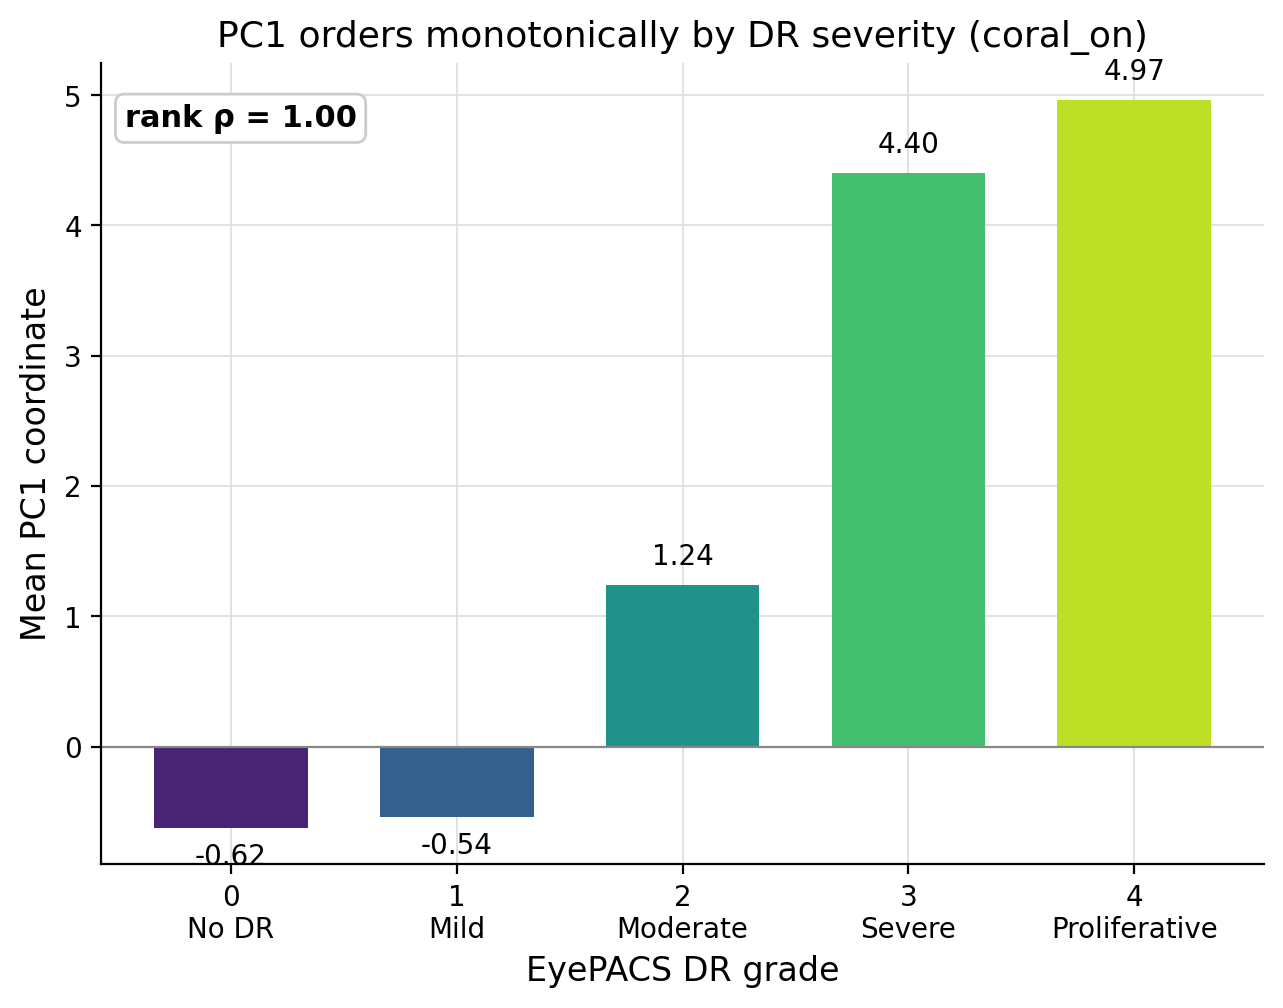

In [ ]:
show(figures.fig_severity_ordering(cfg))

## Figure 9 — Acquisition correlation before/after

The PC1 ↔ black-border Spearman ρ (EyePACS): Phase 1 (−0.274) vs Phase 2
`coral_on` (+0.011), against the |ρ| < 0.10 target band. It quantifies the
acquisition axis collapsing — the mechanism behind the marquee before/after
figure.

[figures] wrote fig09_acquisition_rho: fig09_acquisition_rho.png, fig09_acquisition_rho.pdf


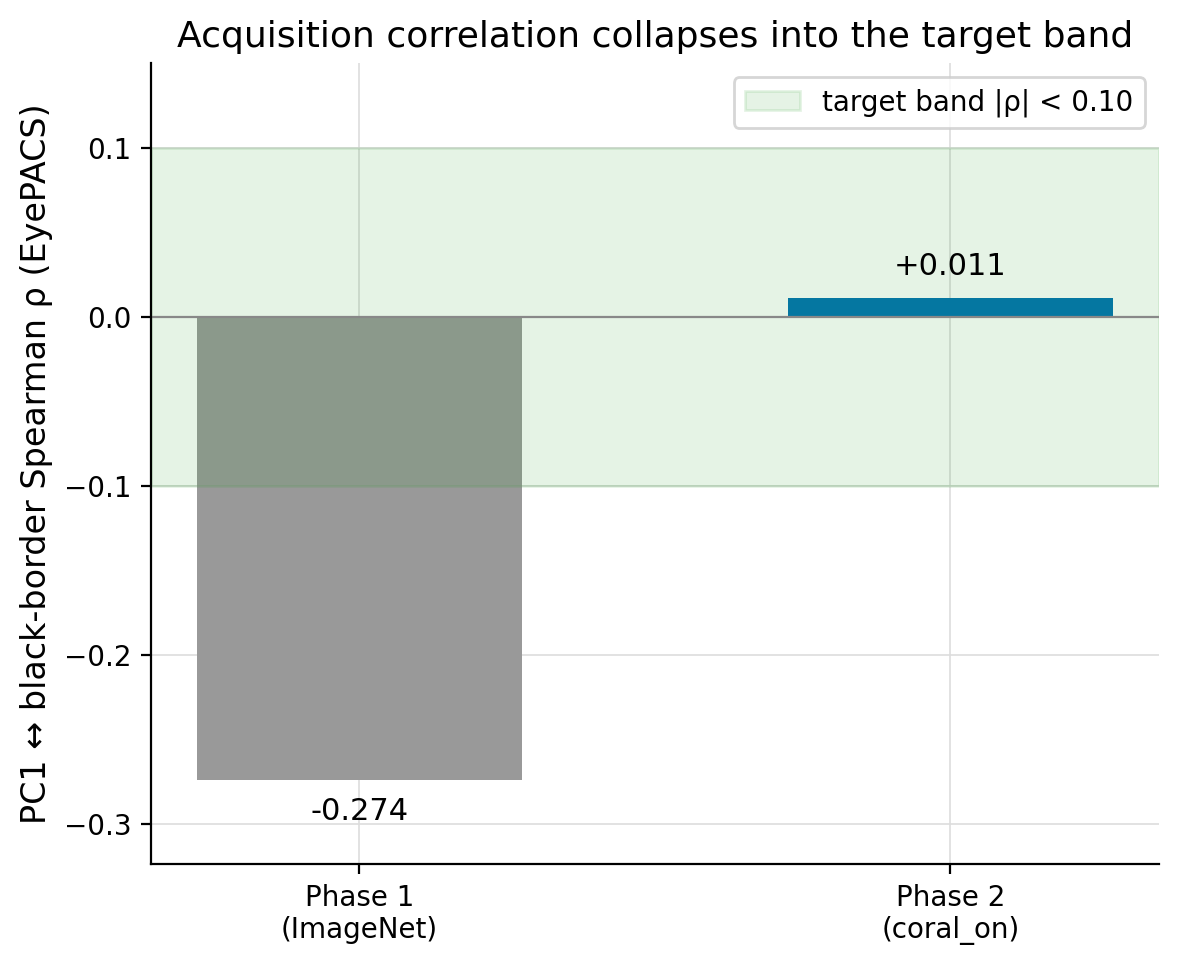

In [ ]:
show(figures.fig_acquisition_rho_before_after(cfg))

## 3. Output folder

List everything written to the `figures/` directory so the reader can confirm
each figure was saved as both PNG and PDF (plus the summary-table CSV).

In [ ]:
# Confirm the artefacts on Drive.
outputs = figures.list_outputs(cfg)
print(f'{len(outputs)} files in {cfg.figures_dir}:')
for p in outputs:
    print('  ', p.name)

25 files in /content/drive/MyDrive/dissertation/figures:
   fig01_dataset_summary.csv
   fig01_dataset_summary.pdf
   fig01_dataset_summary.png
   fig02_acquisition_pca.pdf
   fig02_acquisition_pca.png
   fig03_example_fundus.pdf
   fig03_example_fundus.png
   fig04a_training_qwk.pdf
   fig04a_training_qwk.png
   fig04b_training_losses.pdf
   fig04b_training_losses.png
   fig05_fid_bar.pdf
   fig05_fid_bar.png
   fig06a_pca_before_after.pdf
   fig06a_pca_before_after.png
   fig06b_pca_after_severity.pdf
   fig06b_pca_after_severity.png
   fig07a_embed_by_dataset.pdf
   fig07a_embed_by_dataset.png
   fig07b_embed_by_severity.pdf
   fig07b_embed_by_severity.png
   fig08_severity_ordering.pdf
   fig08_severity_ordering.png
   fig09_acquisition_rho.pdf
   fig09_acquisition_rho.png


In [ ]:
# Phase 3a implementation
!git -C /content/dr-dissertation fetch origin && git -C /content/dr-dissertation reset --hard origin/main
from google.colab import drive; drive.mount('/content/drive')
%cd /content/dr-dissertation
!python -m src.analysis.calibration_eyepacs --config configs/uncertainty.yaml

HEAD is now at 4eccb2b Phase 3a: TTA uncertainty module and EyePACS calibration baseline
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/dr-dissertation
[1/6] loading frozen model + train-time config
[model] strict load OK: 333/333 tensors (encoder=327, dr_head=2); eval on cuda
[2/6] building EyePACS test loader + TTA augmentation
[eyepacs-cache] copied 8/8 shards to /content/eyepacs_cache
[split] EyePACS random split: train=24576 val=5266 test=5266
[eyepacs-cache] all 8 shards present in /content/eyepacs_cache — skip
[data] EyePACS test loader: 5266 images (seed=42)
[3/6] running TTA over the EyePACS test split
[tta eyepacs_test] 83 batches x (30 augmented + 1 clean) passes on cuda
TTA eyepacs_test:   8% 7/83 [00:51<09:04,  7.16s/batch][tta eyepacs_test] batch 8/83
TTA eyepacs_test:  18% 15/83 [01:47<08:02,  7.09s/batch][tta eyepacs_test] batch 16/83
TTA eyepacs_test:  28% 23/83 [02:44<07:09,  7.

In [ ]:
# Phase 4a implementation
!git -C /content/dr-dissertation fetch origin && git -C /content/dr-dissertation reset --hard origin/main
!git -C /content/dr-dissertation log --oneline -1
from google.colab import drive; drive.mount('/content/drive')
import torch; print("CUDA:", torch.cuda.is_available())

HEAD is now at 2234bad Phase 4a: zero-shot cross-modality OLIVES grading + confidence
2234bad (HEAD -> main, origin/main, origin/HEAD) Phase 4a: zero-shot cross-modality OLIVES grading + confidence
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUDA: True


In [ ]:
# Move into the repo folder so the module path (src.analysis...) resolves correctly
%cd /content/dr-dissertation

# Run the Phase 4a zero-shot grading:
#   - loads the frozen Phase 2 model (colour-fundus-trained DR grader)
#   - applies it to all 3,142 OLIVES near-IR images using TTA (30 augmented passes each)
#   - produces a predicted DR grade + confidence for every OLIVES image
#   - saves predictions, a report, and 4 figures to Drive
# The --config flag points it at the settings file (paths, N=30 passes, etc.)
!python -m src.analysis.zero_shot_grading --config configs/zero_shot.yaml

/content/dr-dissertation
[1/7] loading frozen model + train-time config
[model] strict load OK: 333/333 tensors (encoder=327, dr_head=2); eval on cuda
[2/7] building OLIVES loader (all tiers) + TTA augmentation
[data] OLIVES loader: 3142 images (all tiers)
[3/7] running TTA over OLIVES (idempotent cache)
[tta olives] 50 batches x (30 augmented + 1 clean) passes on cuda
TTA olives:   8% 4/50 [00:29<05:31,  7.21s/batch][tta olives] batch 5/50
TTA olives:  18% 9/50 [01:03<04:45,  6.97s/batch][tta olives] batch 10/50
TTA olives:  28% 14/50 [01:39<04:14,  7.06s/batch][tta olives] batch 15/50
TTA olives:  38% 19/50 [02:15<03:44,  7.23s/batch][tta olives] batch 20/50
TTA olives:  48% 24/50 [02:51<03:09,  7.27s/batch][tta olives] batch 25/50
TTA olives:  58% 29/50 [03:27<02:30,  7.18s/batch][tta olives] batch 30/50
TTA olives:  68% 34/50 [04:03<01:55,  7.22s/batch][tta olives] batch 35/50
TTA olives:  78% 39/50 [04:40<01:19,  7.25s/batch][tta olives] batch 40/50
TTA olives:  88% 44/50 [05:16<0

In [ ]:
#Phase 4b: characterise the cross-modality DR-grading failure
!git -C /content/dr-dissertation fetch origin && git -C /content/dr-dissertation reset --hard origin/main
!git -C /content/dr-dissertation log --oneline -1
from google.colab import drive; drive.mount('/content/drive')
%cd /content/dr-dissertation
!python -m src.analysis.dr_failure_characterisation --config configs/zero_shot.yaml

HEAD is now at bf8ac3b Phase 4b: characterise the cross-modality DR-grading failure
bf8ac3b (HEAD -> main, origin/main, origin/HEAD) Phase 4b: characterise the cross-modality DR-grading failure
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/dr-dissertation
[1/5] loading Phase 4a predictions
[data] loaded 3142 predictions from olives_dr_predictions.csv
[2/5] computing per-image brightness (appearance test)
[brightness] computed mean intensity for 3142 images
[3/5] running the failure-characterisation analysis
[4/5] rendering figures
[figures] wrote phase4b_fig1_grade_vs_cst: phase4b_fig1_grade_vs_cst.png, phase4b_fig1_grade_vs_cst.pdf
[figures] wrote phase4b_fig2_grade_vs_burden: phase4b_fig2_grade_vs_burden.png, phase4b_fig2_grade_vs_burden.pdf
[figures] wrote phase4b_fig3_grade_vs_brightness: phase4b_fig3_grade_vs_brightness.png, phase4b_fig3_grade_vs_brightness.pdf
[figures] wrote phase4b_fig4_

In [ ]:
# Fetch the latest commits from GitHub, then force Colab's copy to match origin/main EXACTLY.
# reset --hard discards any local Colab-side changes and points HEAD at the freshly-fetched origin/main.
# (Safe here because we never edit code in Colab — we only run it. All edits happen in VS Code + push from PowerShell.)
!git -C /content/dr-dissertation fetch origin && git -C /content/dr-dissertation reset --hard origin/main

# Print the commit Colab is now on — VERIFY this shows "7180f0f Phase 4c" before running anything.
# This is the guard against the wrong-commit trap (running stale code because the pull didn't land the newest commit).
!git -C /content/dr-dissertation log --oneline -1

remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 9 (delta 5), reused 9 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 11.82 KiB | 3.94 MiB/s, done.
From https://github.com/savita10/dr-dissertation
   bf8ac3b..7180f0f  main       -> origin/main
HEAD is now at 7180f0f Phase 4c: in-domain multi-task evaluation (biomarkers/CST/BCVA)
7180f0f (HEAD -> main, origin/main, origin/HEAD) Phase 4c: in-domain multi-task evaluation (biomarkers/CST/BCVA)


In [ ]:
# Mount Google Drive so the script can read the frozen checkpoint + OLIVES tensors and write results back.
from google.colab import drive; drive.mount('/content/drive')

# Confirm a GPU is attached — Phase 4c does real forward passes, so it needs CUDA (must print True).
import torch; print("CUDA:", torch.cuda.is_available())

# Move into the repo so the module path (src.analysis...) resolves, then run the in-domain evaluation.
%cd /content/dr-dissertation
!python -m src.analysis.indomain_evaluation --config configs/indomain_eval.yaml

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUDA: True
/content/dr-dissertation
[1/6] loading frozen model + train-time config
[model] strict load OK: 333/333 tensors (encoder=327, dr_head=2); eval on cuda
[2/6] reconstructing held-out OLIVES test split (patient-aware, seed 42)
[split] OLIVES patient-aware split (tier coverage):
  train n= 2611  tier0= 1546 tier1=  931 tier2=  134
  val   n=  272  tier0=    0 tier1=  242 tier2=   30
  test  n=  259  tier0=    0 tier1=  231 tier2=   28
[stats] regression stats loaded from /content/drive/MyDrive/dissertation/preprocessed/regression_stats.json
[split] OLIVES TEST split (seed=42): 259 images, 13 patients, tier1=259, tier2=28
[3/6] forward pass over the test split (no TTA — point metrics)
[forward] batch 1/5
[forward] batch 2/5
[forward] batch 3/5
[forward] batch 4/5
[forward] batch 5/5
[4/6] computing biomarker + CST + BCVA metrics (real units, bootstrap C

In [ ]:
# Pull the experiment
!git -C /content/dr-dissertation fetch origin && git -C /content/dr-dissertation reset --hard origin/main
# Verify Colab is on your greyscale commit
!git -C /content/dr-dissertation log --oneline -1